In [1]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset Configuration

In [2]:
# Define paths
data_dir = Path('pcb-defect-dataset')
yaml_path = data_dir / 'data.yaml'

# Load YAML configuration
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

# Display configuration
print("Dataset Configuration:")
print("=" * 50)
print(f"Path: {config['path']}")
print(f"\nSplits:")
print(f"  - Train: {config['train']}")
print(f"  - Val: {config['val']}")
print(f"  - Test: {config['test']}")
print(f"\nClasses ({len(config['names'])} total):")
for idx, name in config['names'].items():
    print(f"  {idx}: {name}")

Dataset Configuration:
Path: ../pcb-defect-dataset

Splits:
  - Train: train
  - Val: val
  - Test: test

Classes (6 total):
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper


## 2. Dataset Size Analysis


Dataset Statistics:
Split  Images  Labels Match
Train    8534    8534     ✓
  Val    1066    1066     ✓
 Test    1068    1068     ✓

Total Images: 10668


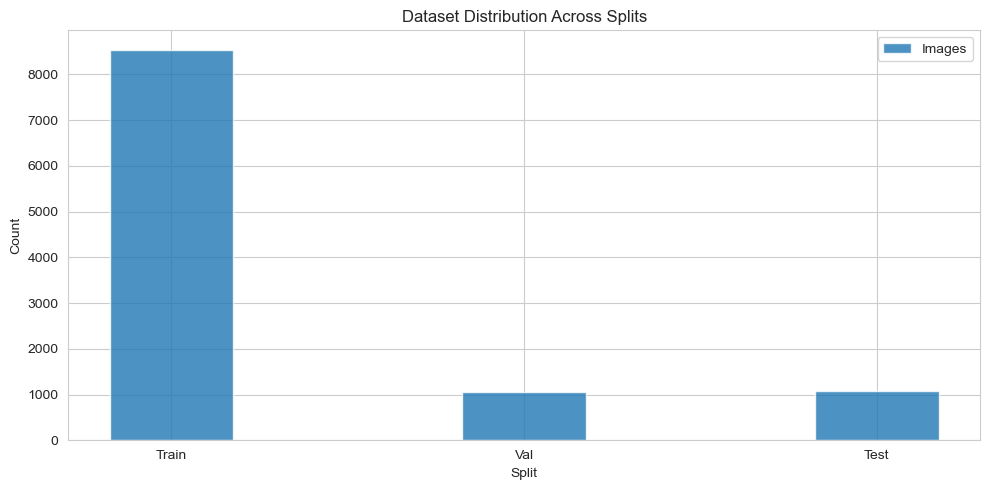

In [3]:
# Count images and labels in each split
splits = ['train', 'val', 'test']
dataset_stats = []

for split in splits:
    img_dir = data_dir / split / 'images'
    label_dir = data_dir / split / 'labels'
    
    num_images = len(list(img_dir.glob('*.jpg'))) if img_dir.exists() else 0
    num_labels = len(list(label_dir.glob('*.txt'))) if label_dir.exists() else 0
    
    dataset_stats.append({
        'Split': split.capitalize(),
        'Images': num_images,
        'Labels': num_labels,
        'Match': '✓' if num_images == num_labels else '✗'
    })

df_stats = pd.DataFrame(dataset_stats)
print("\nDataset Statistics:")
print("=" * 50)
print(df_stats.to_string(index=False))
print(f"\nTotal Images: {df_stats['Images'].sum()}")

# Visualize distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
x = np.arange(len(splits))
width = 0.35

ax.bar(x, df_stats['Images'], width, label='Images', alpha=0.8)
ax.set_xlabel('Split')
ax.set_ylabel('Count')
ax.set_title('Dataset Distribution Across Splits')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in splits])
ax.legend()
plt.tight_layout()
plt.show()

## 3. Class Distribution Analysis

In [4]:
def parse_yolo_labels(label_path):
    """Parse YOLO format labels from a text file"""
    annotations = []
    if not os.path.exists(label_path):
        return annotations
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
                annotations.append({
                    'class_id': class_id,
                    'x_center': x_center,
                    'y_center': y_center,
                    'width': width,
                    'height': height,
                    'area': width * height
                })
    return annotations

# Collect all annotations
all_annotations = []
split_class_counts = {split: Counter() for split in splits}

for split in splits:
    label_dir = data_dir / split / 'labels'
    if not label_dir.exists():
        continue
    
    for label_file in label_dir.glob('*.txt'):
        annotations = parse_yolo_labels(label_file)
        for ann in annotations:
            ann['split'] = split
            all_annotations.append(ann)
            split_class_counts[split][ann['class_id']] += 1

df_annotations = pd.DataFrame(all_annotations)
print(f"\nTotal Annotations: {len(df_annotations)}")
print(f"Annotations per split:")
print(df_annotations['split'].value_counts())


Total Annotations: 21664
Annotations per split:
split
train    17342
val       2164
test      2158
Name: count, dtype: int64


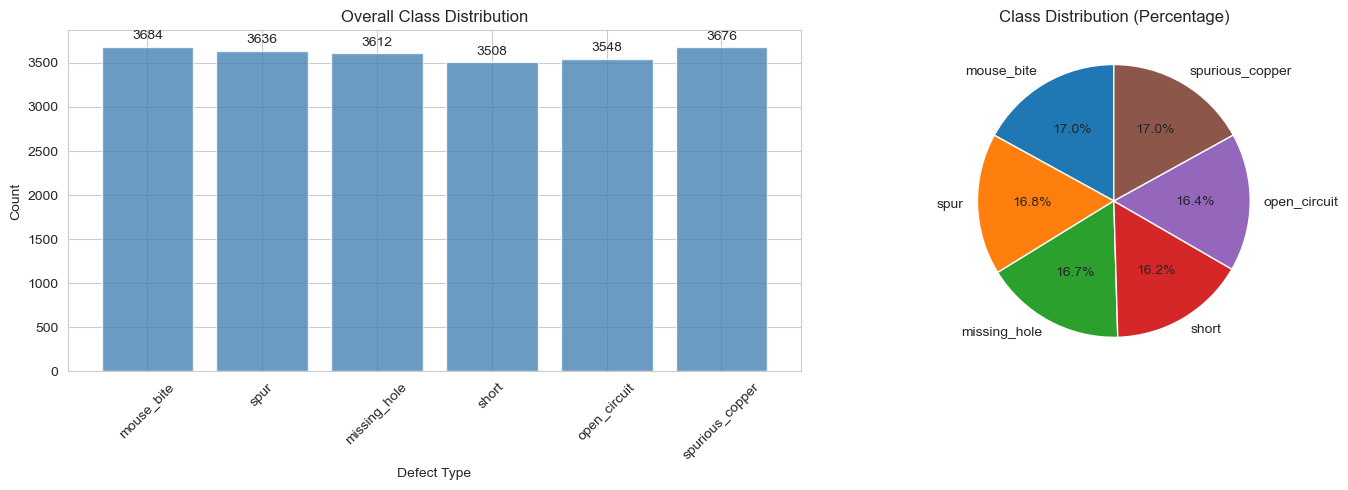


Class Distribution by Split:

TRAIN:
  mouse_bite          : 2980
  spur                : 2919
  missing_hole        : 2902
  short               : 2731
  open_circuit        : 2844
  spurious_copper     : 2966

VAL:
  mouse_bite          :  372
  spur                :  369
  missing_hole        :  331
  short               :  411
  open_circuit        :  359
  spurious_copper     :  322

TEST:
  mouse_bite          :  332
  spur                :  348
  missing_hole        :  379
  short               :  366
  open_circuit        :  345
  spurious_copper     :  388


In [5]:
# Overall class distribution
class_counts = df_annotations['class_id'].value_counts().sort_index()
class_names_list = [config['names'][i] for i in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
axes[0].bar(class_names_list, class_counts.values, alpha=0.8, color='steelblue')
axes[0].set_xlabel('Defect Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall Class Distribution')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom')

# Pie chart
axes[1].pie(class_counts.values, labels=class_names_list, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

# Class distribution per split
print("\nClass Distribution by Split:")
print("=" * 70)
for split in splits:
    print(f"\n{split.upper()}:")
    counts = split_class_counts[split]
    for class_id in sorted(counts.keys()):
        class_name = config['names'][class_id]
        print(f"  {class_name:20s}: {counts[class_id]:4d}")

## 4. Defect Size Analysis

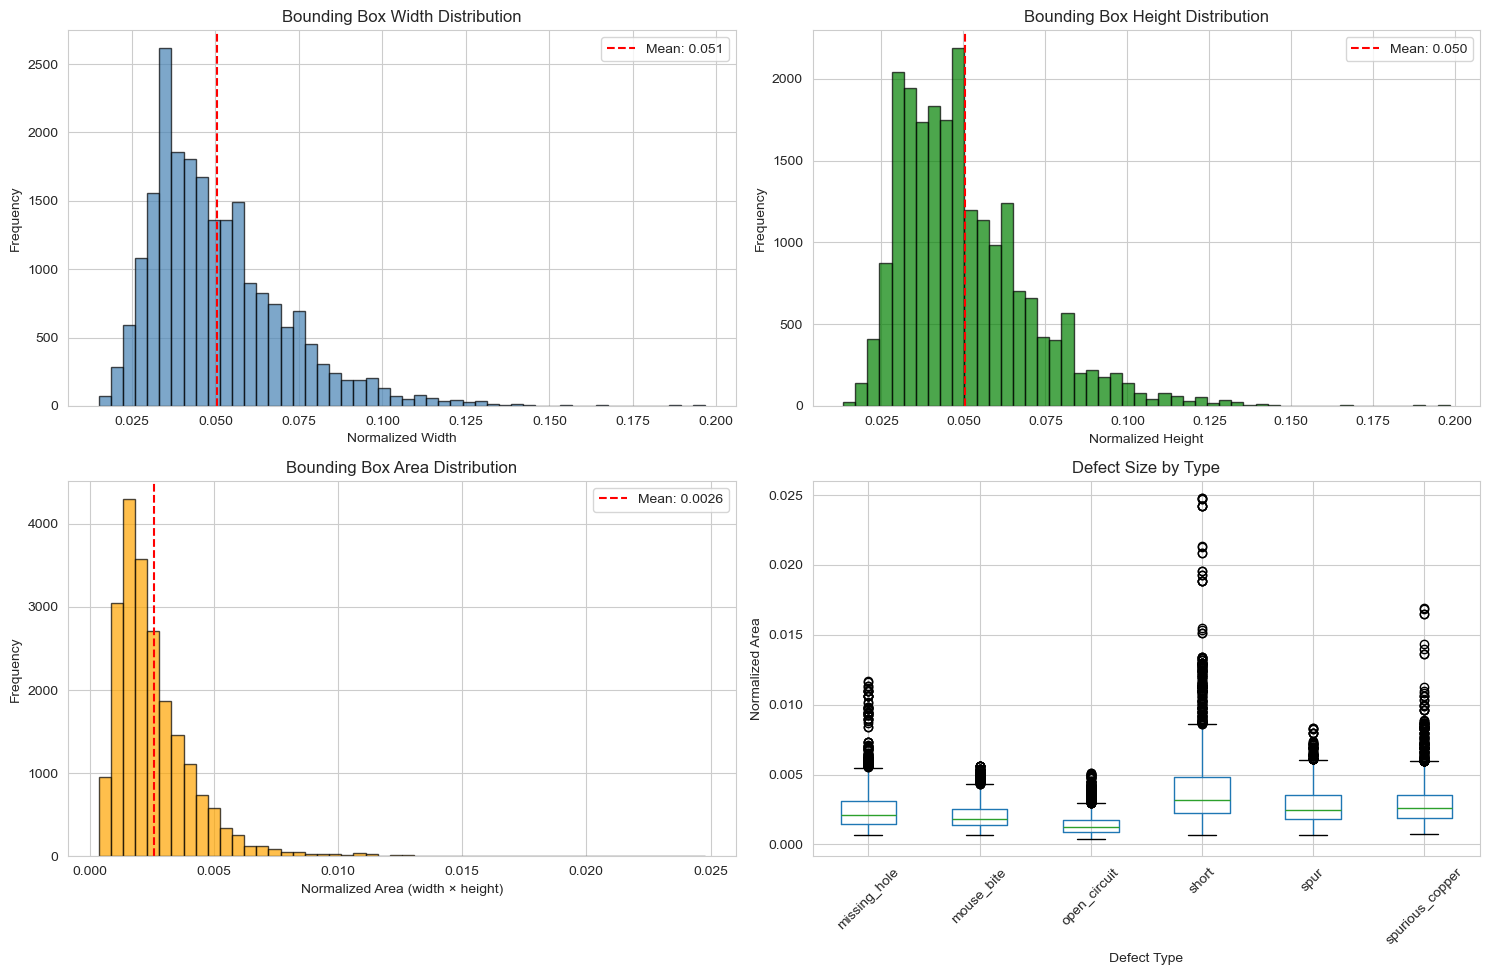


Bounding Box Statistics:
Width  - Mean: 0.0505, Std: 0.0202
Height - Mean: 0.0505, Std: 0.0203
Area   - Mean: 0.0026, Std: 0.0018


In [6]:
# Analyze bounding box sizes
df_annotations['class_name'] = df_annotations['class_id'].map(config['names'])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Width distribution
axes[0, 0].hist(df_annotations['width'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Normalized Width')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Bounding Box Width Distribution')
axes[0, 0].axvline(df_annotations['width'].mean(), color='red', linestyle='--', label=f'Mean: {df_annotations["width"].mean():.3f}')
axes[0, 0].legend()

# Height distribution
axes[0, 1].hist(df_annotations['height'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_xlabel('Normalized Height')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Bounding Box Height Distribution')
axes[0, 1].axvline(df_annotations['height'].mean(), color='red', linestyle='--', label=f'Mean: {df_annotations["height"].mean():.3f}')
axes[0, 1].legend()

# Area distribution
axes[1, 0].hist(df_annotations['area'], bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_xlabel('Normalized Area (width × height)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Bounding Box Area Distribution')
axes[1, 0].axvline(df_annotations['area'].mean(), color='red', linestyle='--', label=f'Mean: {df_annotations["area"].mean():.4f}')
axes[1, 0].legend()

# Box plot by class
df_annotations.boxplot(column='area', by='class_name', ax=axes[1, 1], rot=45)
axes[1, 1].set_xlabel('Defect Type')
axes[1, 1].set_ylabel('Normalized Area')
axes[1, 1].set_title('Defect Size by Type')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Print statistics
print("\nBounding Box Statistics:")
print("=" * 50)
print(f"Width  - Mean: {df_annotations['width'].mean():.4f}, Std: {df_annotations['width'].std():.4f}")
print(f"Height - Mean: {df_annotations['height'].mean():.4f}, Std: {df_annotations['height'].std():.4f}")
print(f"Area   - Mean: {df_annotations['area'].mean():.4f}, Std: {df_annotations['area'].std():.4f}")

## 5. Image Properties Analysis


Image Properties (sampled):
Dimensions - Width: [600]
Dimensions - Height: [600]
Aspect Ratio - Mean: 1.000
Color Mode: ['RGB']


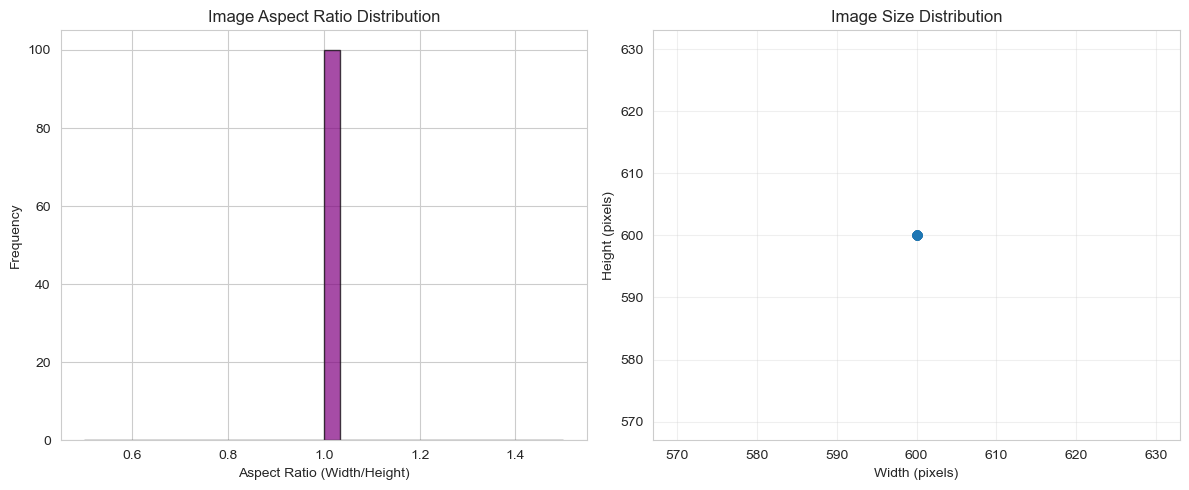

In [7]:
# Sample images to analyze
sample_images = []
for split in ['train']:
    img_dir = data_dir / split / 'images'
    if img_dir.exists():
        imgs = list(img_dir.glob('*.jpg'))[:100]  # Sample 100 images
        for img_path in imgs:
            img = Image.open(img_path)
            sample_images.append({
                'width': img.width,
                'height': img.height,
                'aspect_ratio': img.width / img.height,
                'mode': img.mode
            })

df_images = pd.DataFrame(sample_images)

print("\nImage Properties (sampled):")
print("=" * 50)
print(f"Dimensions - Width: {df_images['width'].unique()}")
print(f"Dimensions - Height: {df_images['height'].unique()}")
print(f"Aspect Ratio - Mean: {df_images['aspect_ratio'].mean():.3f}")
print(f"Color Mode: {df_images['mode'].unique()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Aspect ratio distribution
axes[0].hist(df_images['aspect_ratio'], bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[0].set_xlabel('Aspect Ratio (Width/Height)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Image Aspect Ratio Distribution')

# Size scatter
axes[1].scatter(df_images['width'], df_images['height'], alpha=0.5)
axes[1].set_xlabel('Width (pixels)')
axes[1].set_ylabel('Height (pixels)')
axes[1].set_title('Image Size Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Visual Samples with Annotations

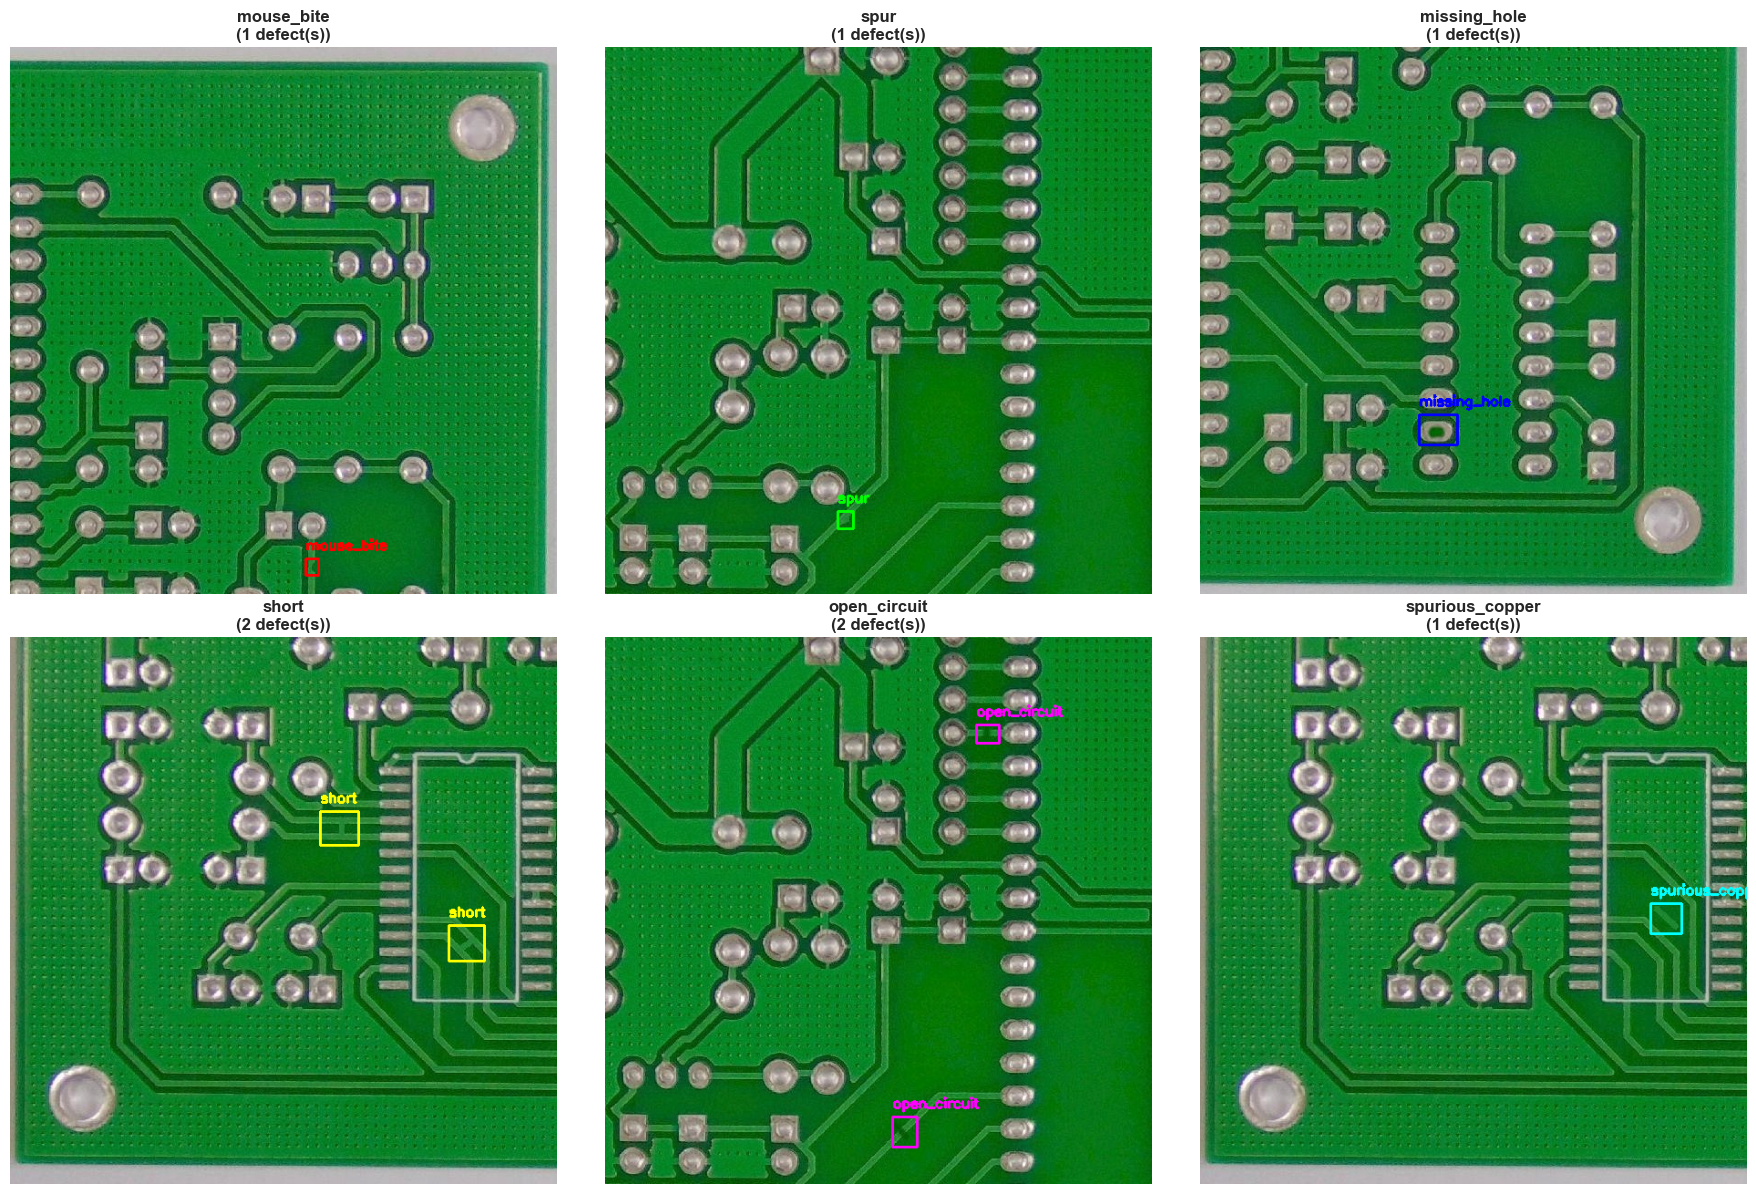

In [8]:
def draw_yolo_boxes(image_path, label_path, class_names):
    """Draw bounding boxes on image"""
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    annotations = parse_yolo_labels(label_path)
    
    colors = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255),
        (255, 255, 0), (255, 0, 255), (0, 255, 255)
    ]
    
    for ann in annotations:
        class_id = ann['class_id']
        x_center = ann['x_center'] * w
        y_center = ann['y_center'] * h
        box_w = ann['width'] * w
        box_h = ann['height'] * h
        
        x1 = int(x_center - box_w / 2)
        y1 = int(y_center - box_h / 2)
        x2 = int(x_center + box_w / 2)
        y2 = int(y_center + box_h / 2)
        
        color = colors[class_id % len(colors)]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        
        label = class_names[class_id]
        cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 
                   0.5, color, 2)
    
    return img

# Display samples from each class
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, class_id in enumerate(sorted(config['names'].keys())):
    class_name = config['names'][class_id]
    
    # Find an image with this defect
    found = False
    for split in ['train', 'val']:
        label_dir = data_dir / split / 'labels'
        img_dir = data_dir / split / 'images'
        
        if not label_dir.exists():
            continue
            
        for label_file in label_dir.glob('*.txt'):
            annotations = parse_yolo_labels(label_file)
            if any(ann['class_id'] == class_id for ann in annotations):
                img_path = img_dir / (label_file.stem + '.jpg')
                if img_path.exists():
                    img = draw_yolo_boxes(img_path, label_file, config['names'])
                    axes[idx].imshow(img)
                    axes[idx].set_title(f'{class_name}\n({len(annotations)} defect(s))', fontsize=12, fontweight='bold')
                    axes[idx].axis('off')
                    found = True
                    break
        
        if found:
            break

plt.tight_layout()
plt.show()

## 7. Key Findings Summary

In [9]:
print("\n" + "="*70)
print(" "*20 + "KEY FINDINGS SUMMARY")
print("="*70)

print("\n1. DATASET COMPOSITION:")
print(f"   - Total Images: {df_stats['Images'].sum()}")
print(f"   - Total Annotations: {len(df_annotations)}")
print(f"   - Defect Classes: {len(config['names'])}")
print(f"   - Image Format: {df_images['mode'].mode()[0] if not df_images.empty else 'RGB'}")
print(f"   - Image Size: 600x600 pixels (standard)")

print("\n2. CLASS IMBALANCE:")
max_class = class_counts.idxmax()
min_class = class_counts.idxmin()
print(f"   - Most common: {config['names'][max_class]} ({class_counts[max_class]} samples)")
print(f"   - Least common: {config['names'][min_class]} ({class_counts[min_class]} samples)")
print(f"   - Imbalance ratio: {class_counts[max_class] / class_counts[min_class]:.2f}x")

print("\n3. DEFECT CHARACTERISTICS:")
print(f"   - Average defect size (normalized area): {df_annotations['area'].mean():.4f}")
print(f"   - Size range: {df_annotations['area'].min():.4f} to {df_annotations['area'].max():.4f}")
print(f"   - Most defects are: {'small' if df_annotations['area'].mean() < 0.1 else 'medium-to-large'}")

print("\n4. RECOMMENDATIONS:")
print("   - Consider data augmentation to balance classes")
print("   - Use weighted loss function to handle class imbalance")
print("   - Small defects may require higher resolution or attention mechanisms")
print("   - Standard 600x600 images are suitable for modern detectors")

print("\n" + "="*70)


                    KEY FINDINGS SUMMARY

1. DATASET COMPOSITION:
   - Total Images: 10668
   - Total Annotations: 21664
   - Defect Classes: 6
   - Image Format: RGB
   - Image Size: 600x600 pixels (standard)

2. CLASS IMBALANCE:
   - Most common: mouse_bite (3684 samples)
   - Least common: short (3508 samples)
   - Imbalance ratio: 1.05x

3. DEFECT CHARACTERISTICS:
   - Average defect size (normalized area): 0.0026
   - Size range: 0.0004 to 0.0248
   - Most defects are: small

4. RECOMMENDATIONS:
   - Consider data augmentation to balance classes
   - Use weighted loss function to handle class imbalance
   - Small defects may require higher resolution or attention mechanisms
   - Standard 600x600 images are suitable for modern detectors

